In [134]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix , ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier



In [135]:
model1 = AdaBoostClassifier()
model2 = RandomForestClassifier(max_features=100 , max_depth=20 , random_state=50)
model3 = DecisionTreeClassifier(max_leaf_nodes=3 , max_depth=6 , random_state=42)
model4 = SVC(probability=True )
model5 = KNeighborsClassifier(n_neighbors=5)
model6 = LogisticRegression()
ensemble_model = VotingClassifier(estimators=[('Ab', model1) , ('Rf' , model2) , ('Dt' , model3) , ('Sv' , model4) , ('Kn' , model5)])

In [136]:
data = pd.read_csv('/content/plant_disease_dataset.csv')
data

,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,32.615149,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0
...,...,...,...,...,...
9995,31.505510,81.939137,22.406822,5.862952,1
9996,15.008275,86.886833,10.503881,4.070539,0
9997,21.473416,81.891770,13.426869,7.101583,0
9998,27.478828,88.567649,9.719659,7.732620,0


In [137]:
data.isnull().sum()

,0
temperature,0
humidity,0
rainfall,0
soil_pH,0
disease_present,0


In [138]:
data.shape

(10000, 5)

In [139]:
data.columns

Index(['temperature', 'humidity', 'rainfall', 'soil_pH', 'disease_present'], dtype='object')

In [140]:
x = data.drop(['disease_present'] , axis=1)
y = data['disease_present']
print(f"x shape: {x.shape}, y shape: {y.shape}")

x shape: (10000, 4), y shape: (10000,)


In [141]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.25 , random_state=50)
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

x_train shape: (7500, 4), y_train shape: (7500,)
x_test shape: (2500, 4), y_test shape: (2500,)


In [142]:
model1.fit(x_train , y_train)
model1

AdaBoostClassifier()

In [143]:
accuracy_ADA = model1.score(x_test , y_test)
accuracy_ADA

0.8268

In [144]:
model2.fit(x_train , y_train)
model2

RandomForestClassifier(max_depth=20, max_features=100, random_state=50)

In [145]:
accuracy_RF = model2.score(x_test , y_test)
accuracy_RF

0.8604

In [146]:
model3.fit(x_train , y_train)
model3

DecisionTreeClassifier(max_depth=6, max_leaf_nodes=3, random_state=42)

In [147]:
accuracy_DT = model3.score(x_test , y_test)
accuracy_DT

0.7892

In [148]:
model4.fit(x_train , y_train)
model4

SVC(probability=True)

In [149]:
accuracy_SVC = model4.score(x_test , y_test)
accuracy_SVC

0.7708

In [150]:
model5.fit(x_train , y_train)
model5

KNeighborsClassifier()

In [151]:
accuracy_KNN = model5.score(x_test , y_test)
accuracy_KNN

0.7808

In [152]:
model6.fit(x_train , y_train)
model6

LogisticRegression()

In [153]:
accuracy_LR = model6.score(x_test , y_test)
accuracy_LR

0.77

In [154]:
ensemble_model = VotingClassifier(estimators=[('Ab', model1) , ('Rf' , model2) , ('Dt' , model3) , ('Sv' , model4) , ('Kn' , model5) , ('Lg' , model6)] , voting='hard')
ensemble_model.fit(x_train , y_train)
ensemble_model

VotingClassifier(estimators=[('Ab', AdaBoostClassifier()),
                             ('Rf',
                              RandomForestClassifier(max_depth=20,
                                                     max_features=100,
                                                     random_state=50)),
                             ('Dt',
                              DecisionTreeClassifier(max_depth=6,
                                                     max_leaf_nodes=3,
                                                     random_state=42)),
                             ('Sv', SVC(probability=True)),
                             ('Kn', KNeighborsClassifier()),
                             ('Lg', LogisticRegression())])

In [155]:
accuracy_VC=ensemble_model.score(x_test , y_test)


In [156]:
model1.fit(x_train , y_train)
classification_report1 = classification_report(y_test , model1.predict(x_test))
print(classification_report1)

              precision    recall  f1-score   support

           0       0.83      0.97      0.90      1913
           1       0.80      0.35      0.49       587

    accuracy                           0.83      2500
   macro avg       0.81      0.66      0.69      2500
weighted avg       0.82      0.83      0.80      2500



<Axes: >

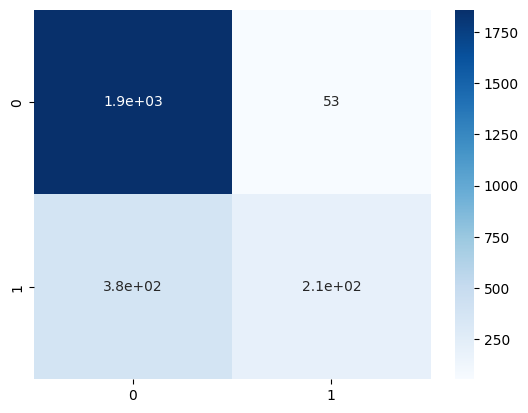

In [157]:
sns.heatmap(confusion_matrix(y_test , model1.predict(x_test)) , annot=True , cmap = 'Blues')

<Axes: >

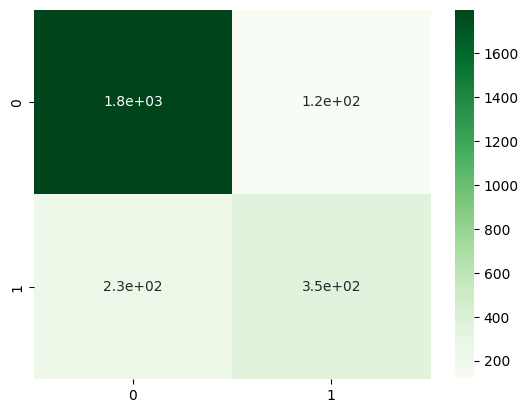

In [158]:
sns.heatmap(confusion_matrix(y_test , model2.predict(x_test)), annot = True , cmap='Greens')

<Axes: >

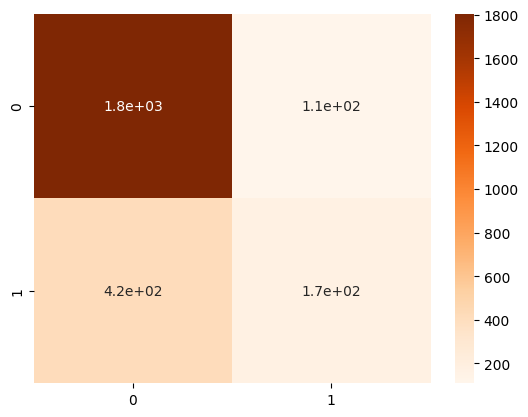

In [159]:
sns.heatmap(confusion_matrix(y_test , model3.predict(x_test)), annot = True , cmap='Oranges')

<Axes: >

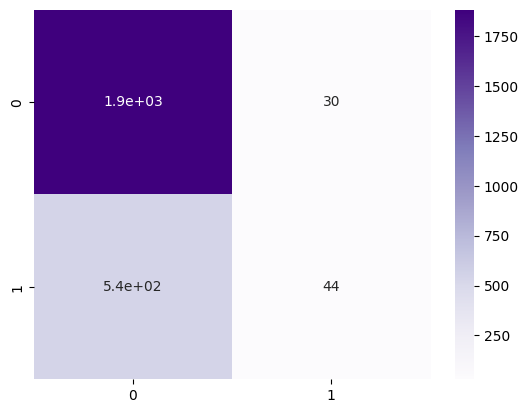

In [160]:
sns.heatmap(confusion_matrix(y_test , model4.predict(x_test)), annot = True , cmap='Purples')

<Axes: >

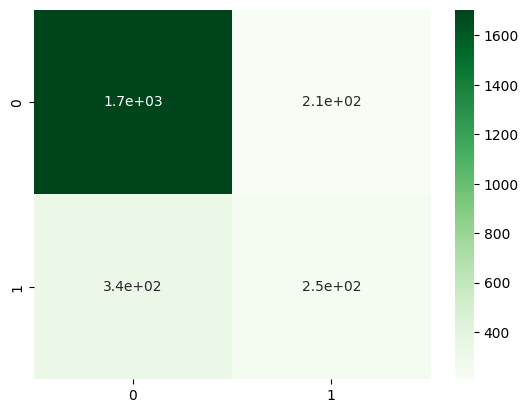

In [161]:
sns.heatmap(confusion_matrix(y_test , model5.predict(x_test)), annot = True , cmap='Greens')

<Axes: >

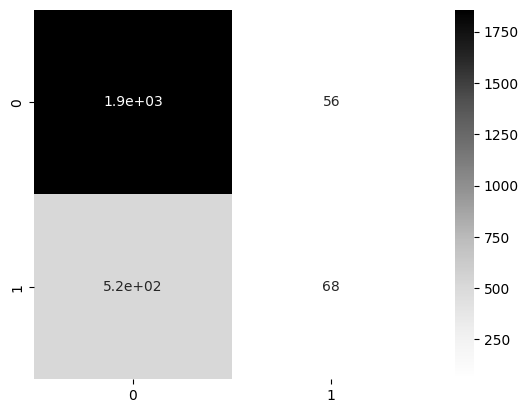

In [162]:
sns.heatmap(confusion_matrix(y_test , model6.predict(x_test)), annot = True , cmap='Greys')

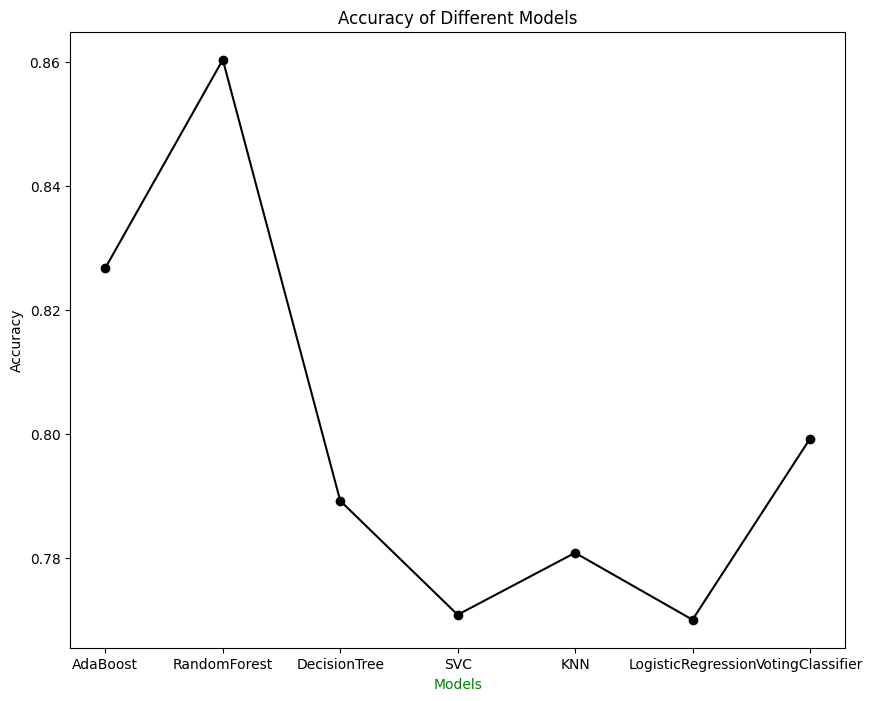

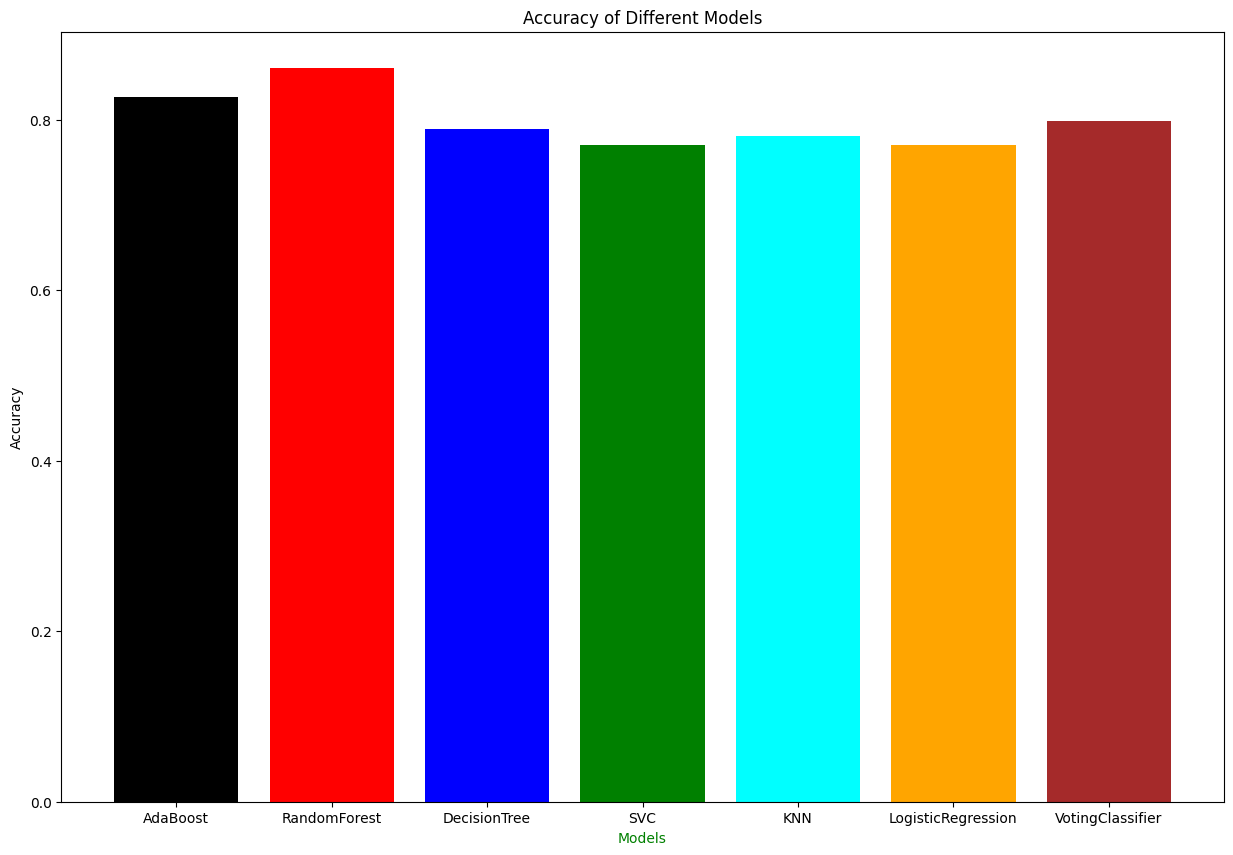

In [164]:
plt.figure(figsize=(10,8))
plt.plot(['AdaBoost' , 'RandomForest' , 'DecisionTree' , 'SVC' , 'KNN' , 'LogisticRegression', 'VotingClassifier'] , [accuracy_ADA , accuracy_RF , accuracy_DT , accuracy_SVC , accuracy_KNN , accuracy_LR , accuracy_VC] , marker='o' , color='Black')
plt.title('Accuracy of Different Models')
plt.xlabel('Models' , color='Green')
plt.ylabel('Accuracy' )
plt.show()
plt.figure(figsize=(15,10))
plt.bar(['AdaBoost' , 'RandomForest' , 'DecisionTree' , 'SVC' , 'KNN' , 'LogisticRegression' , 'VotingClassifier'] , [accuracy_ADA , accuracy_RF , acciuracy_DT , accuracy_SVC , accuracy_KNN , accuracy_LR , accuracy_VC], color=['Black' , 'Red' , 'Blue' , 'Green' , 'Cyan' , 'Orange' ,'Brown'])
plt.title('Accuracy of Different Models')
plt.xlabel('Models' , color='Green')
plt.ylabel('Accuracy' )
plt.show()